# Demonstration of polar coordinate system

For the SVD process to work with in-plane rotational symmetry, we need the projection coordinate system to be in a polar coordinate system rather than the usual Cartesian coordinates. This notebook demonstrates the implemented Panther-EM coordinate systems and their use.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from skimage.transform import warp

from panther_em.utils.coordinates import (
    forward_offset_polar_to_cartesian_mapping,
    inverse_cartesian_to_offset_polar_mapping,
    inverse_offset_polar_to_cartesian_mapping,
)

## Variables for setting up coordinate systems

Note that these are for visualization and demonstration purposes only, their actual values will probably be different in the long-run.

In [2]:
num_angle = 36  # 10 degrees per step
num_radius = 32
max_radius = 50.0

image_shape = (100, 100)
center = (image_shape[0] // 2, image_shape[1] // 2)

In [3]:
angle_indices = np.arange(num_angle)
radius_indices = np.arange(1, num_radius)  # Skip over center

angle_grid, radius_grid = np.meshgrid(angle_indices, radius_indices, indexing="ij")
polar_coords = np.column_stack((radius_grid.ravel(), angle_grid.ravel()))

### Standard polar coordinate system

In [4]:
angle = (polar_coords[:, 1] / num_angle) * (2 * np.pi)
radius = (polar_coords[:, 0] / num_radius) * max_radius
cartesian_standard = np.column_stack((radius * np.sin(angle), radius * np.cos(angle)))
cartesian_standard += center

### Custom offset polar coordinate system

In [5]:
cartesian_offset = forward_offset_polar_to_cartesian_mapping(
    input_coords=polar_coords,
    num_angle=num_angle,
    num_radius=num_radius,
    max_radius=max_radius,
    center=center,
)

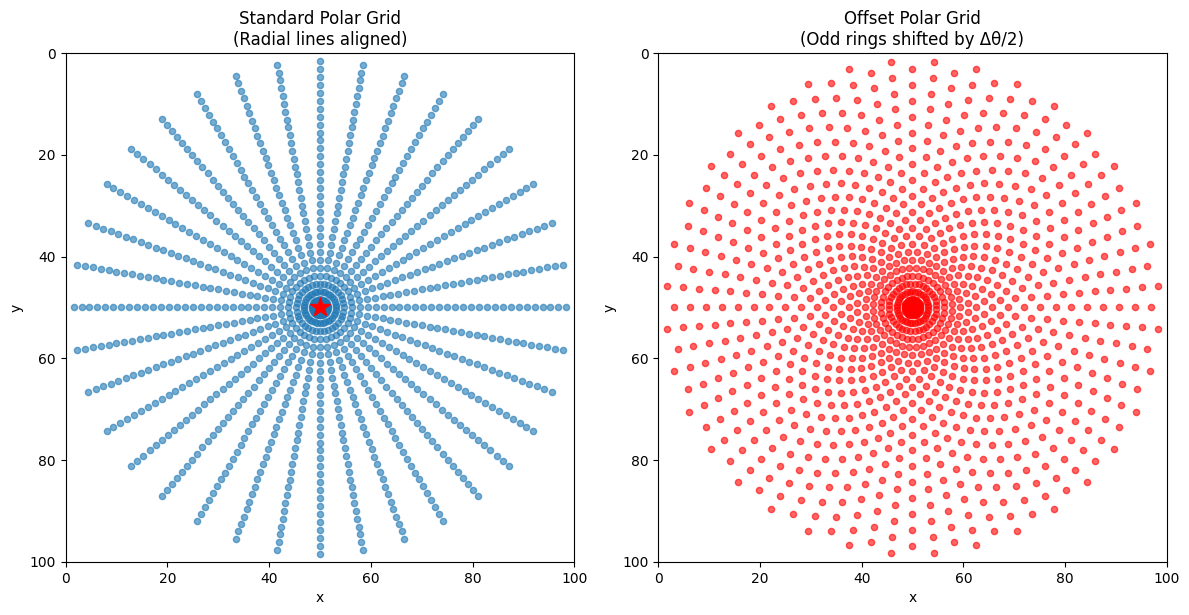

In [6]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Standard polar
axes[0].scatter(cartesian_standard[:, 1], cartesian_standard[:, 0], s=20, alpha=0.6)
axes[0].plot(center[1], center[0], "r*", markersize=15)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(100, 0)
axes[0].set_aspect("equal")
axes[0].set_title("Standard Polar Grid\n(Radial lines aligned)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Offset polar
axes[1].scatter(
    cartesian_offset[:, 1], cartesian_offset[:, 0], s=20, alpha=0.6, c="red"
)
axes[1].plot(center[1], center[0], "r*", markersize=15)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(100, 0)
axes[1].set_aspect("equal")
axes[1].set_title("Offset Polar Grid\n(Odd rings shifted by Δθ/2)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

## Visualizations for the inverse mapping functions

Applications to real image

In [7]:
# Load test image
image = data.camera()
image_shape = image.shape

# Setup parameters
center = (image_shape[0] // 2, image_shape[1] // 2)
max_radius = np.sqrt((image_shape[0] / 2) ** 2 + (image_shape[1] / 2) ** 2)

num_angle = 720
num_radius = 512
polar_shape = (num_angle, num_radius)

print(f"Original image shape: {image_shape}")
print(f"Polar image shape: {polar_shape}")

Original image shape: (512, 512)
Polar image shape: (720, 512)


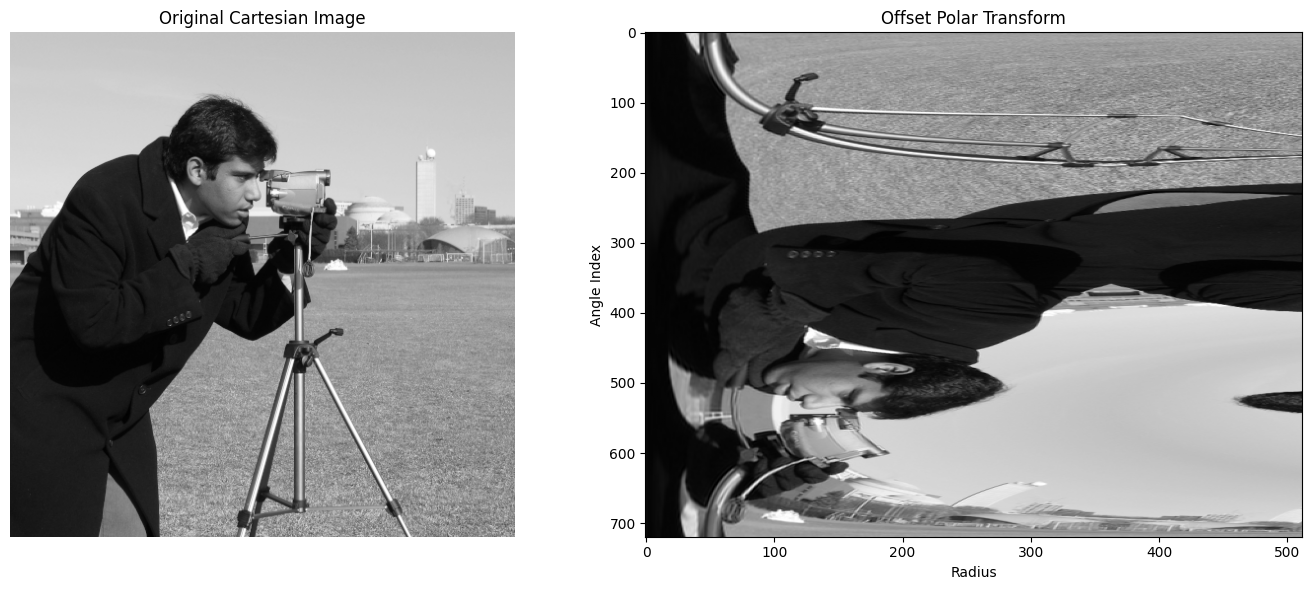

In [8]:
def warp_to_offset_polar(output_coords):
    return inverse_offset_polar_to_cartesian_mapping(
        output_coords, num_angle, num_radius, max_radius, center
    )


polar_image = warp(
    image,
    warp_to_offset_polar,
    output_shape=polar_shape,
    order=5,
    preserve_range=True,
    mode="symmetric",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Cartesian Image")
axes[0].axis("off")

axes[1].imshow(polar_image, cmap="gray", aspect="auto")
axes[1].set_title("Offset Polar Transform")
axes[1].set_xlabel("Radius")
axes[1].set_ylabel("Angle Index")

plt.tight_layout()
plt.show()

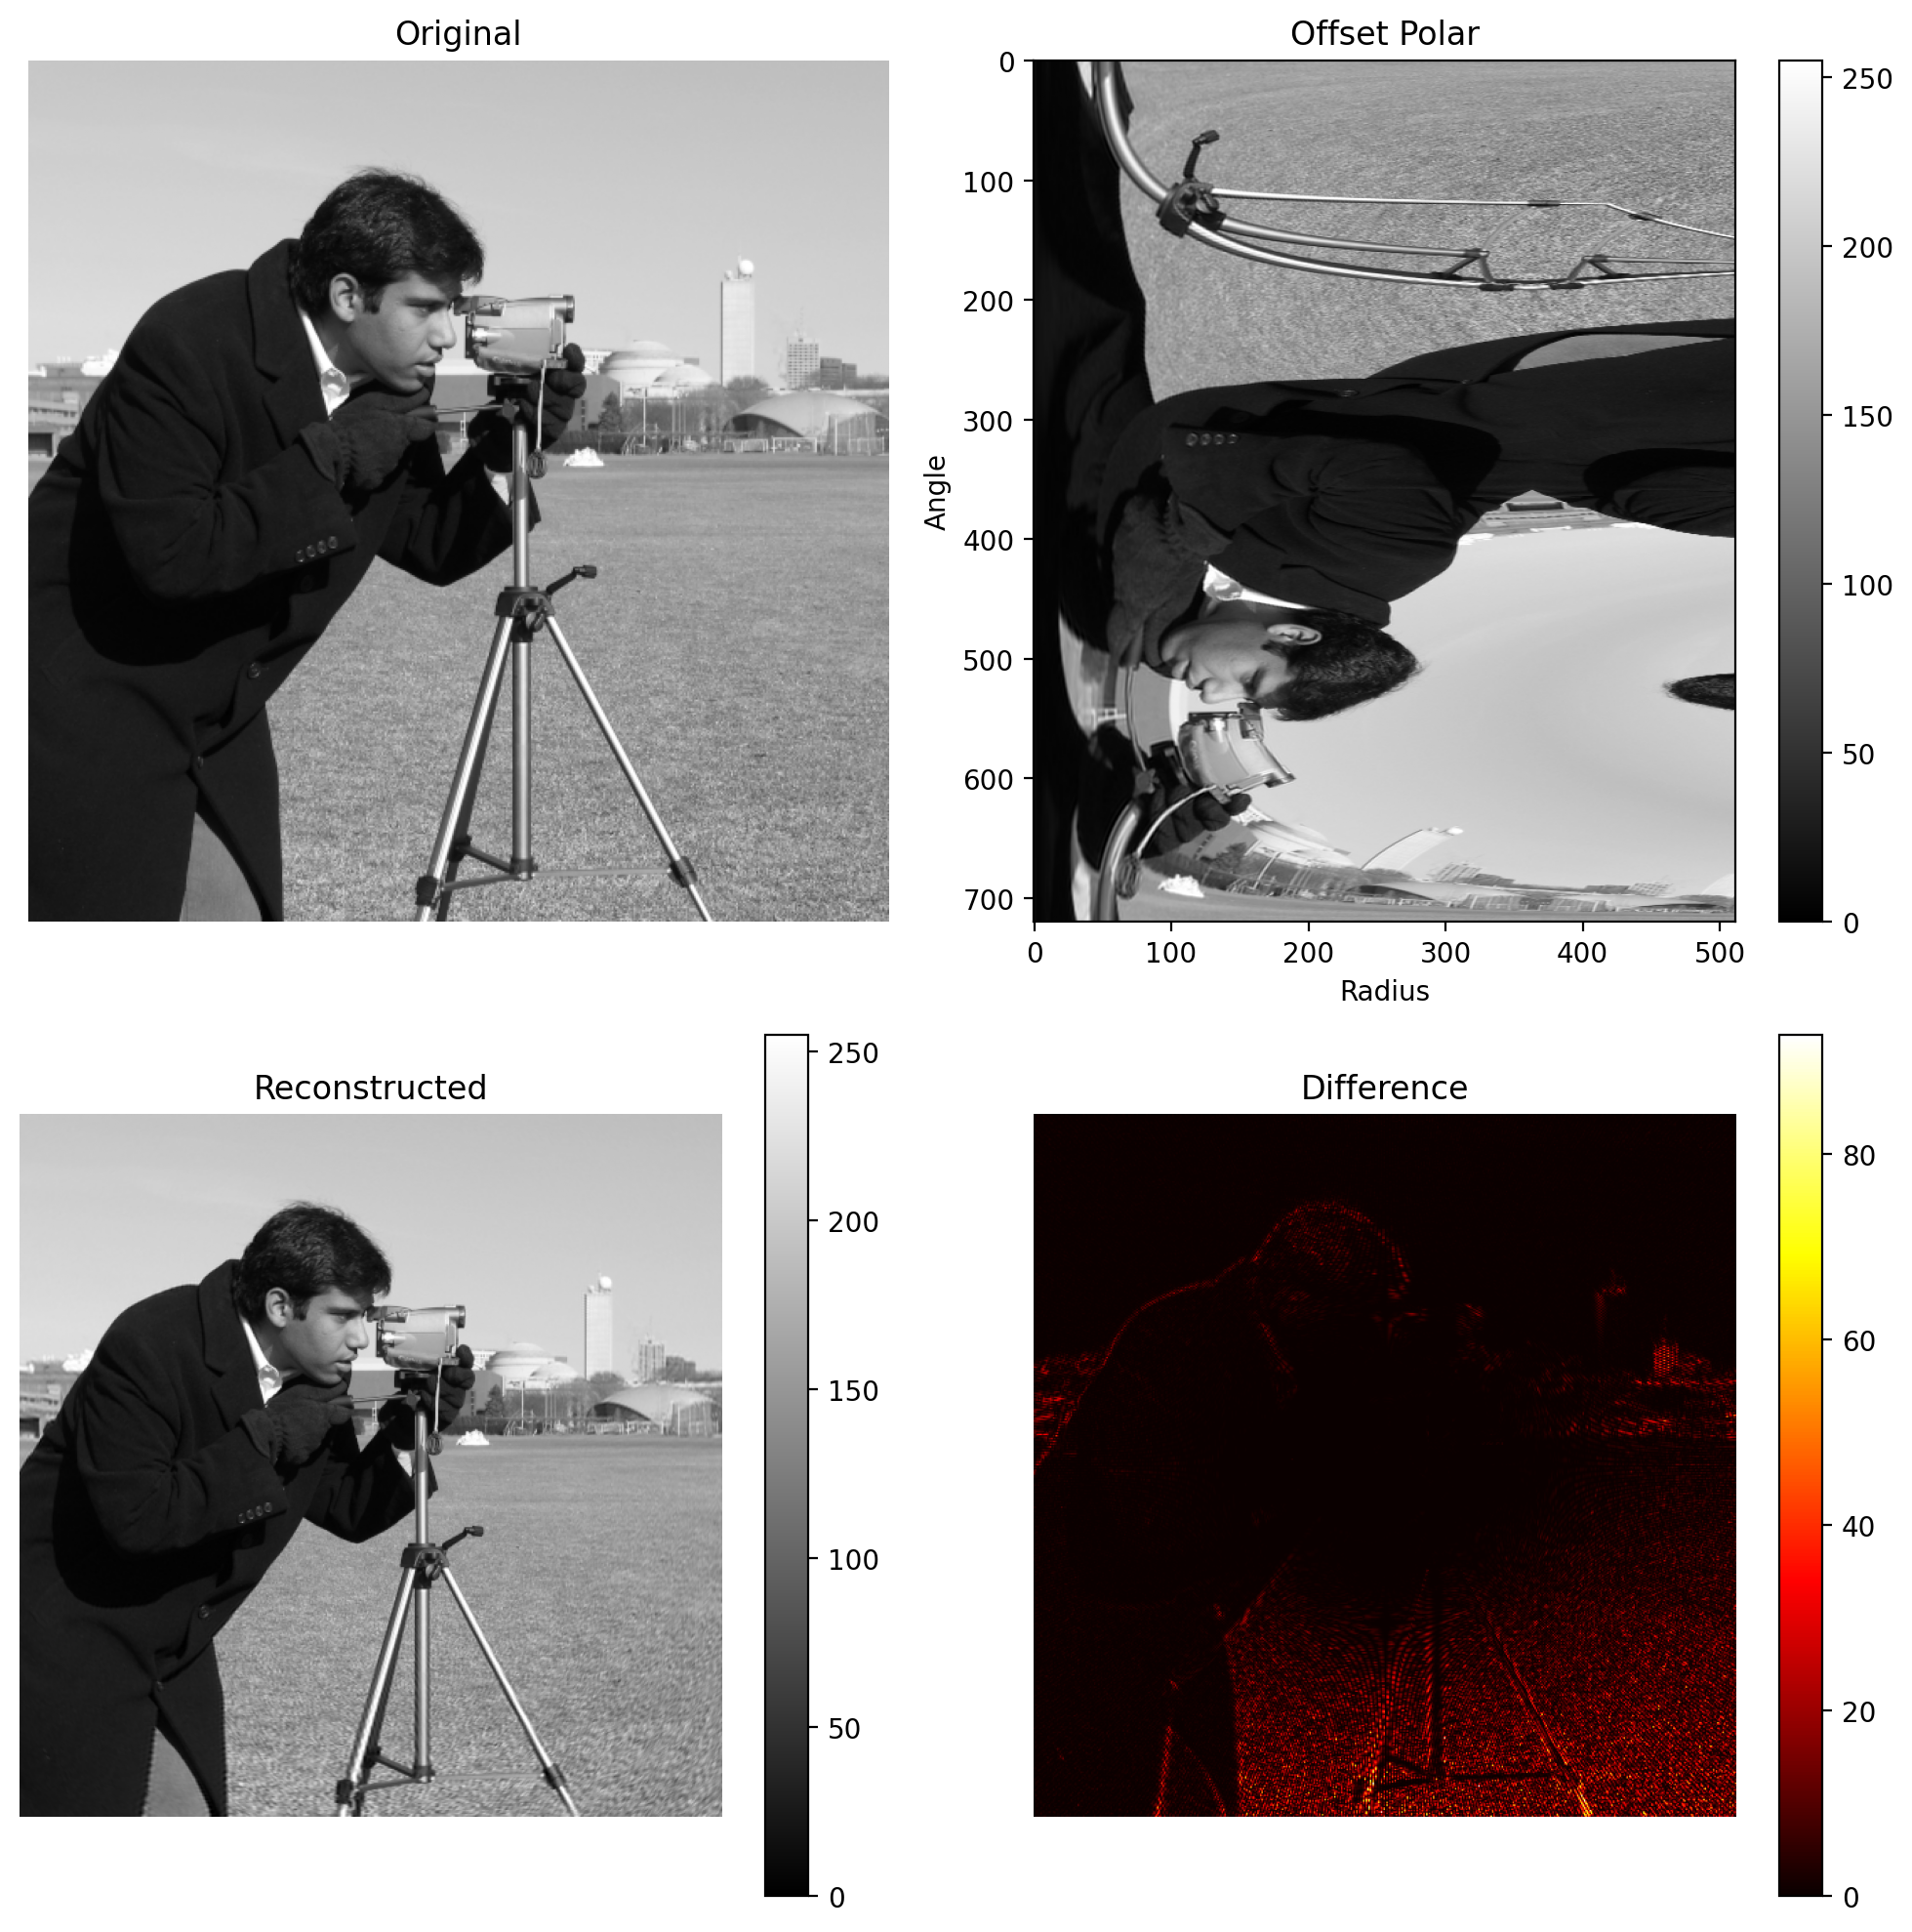


Round-trip quality:
  Mean absolute error: 2.32
  Max absolute error: 92.81
  Correlation: 0.9968


In [9]:
def warp_to_cartesian(output_coords):
    return inverse_cartesian_to_offset_polar_mapping(
        output_coords, num_angle, num_radius, max_radius, center
    )


reconstructed = warp(
    polar_image,
    warp_to_cartesian,
    output_shape=image_shape,
    order=5,
    preserve_range=True,
    mode="symmetric",
)

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=200)
axes = axes.ravel()

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

im1 = axes[1].imshow(polar_image, cmap="gray", aspect="auto")
axes[1].set_title("Offset Polar")
axes[1].set_xlabel("Radius")
axes[1].set_ylabel("Angle")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(reconstructed, cmap="gray")
axes[2].set_title("Reconstructed")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2])

diff = np.abs(image.astype(float) - reconstructed.astype(float))
max_diff = np.max(diff)
im = axes[3].imshow(diff, cmap="hot", vmin=0, vmax=max_diff)
plt.colorbar(im, ax=axes[3])
axes[3].set_title("Difference")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Calculate round-trip error
print("\nRound-trip quality:")
print(f"  Mean absolute error: {np.mean(diff):.2f}")
print(f"  Max absolute error: {np.max(diff):.2f}")
print(
    f"  Correlation: {np.corrcoef(image.flatten(), reconstructed.flatten())[0, 1]:.4f}"
)

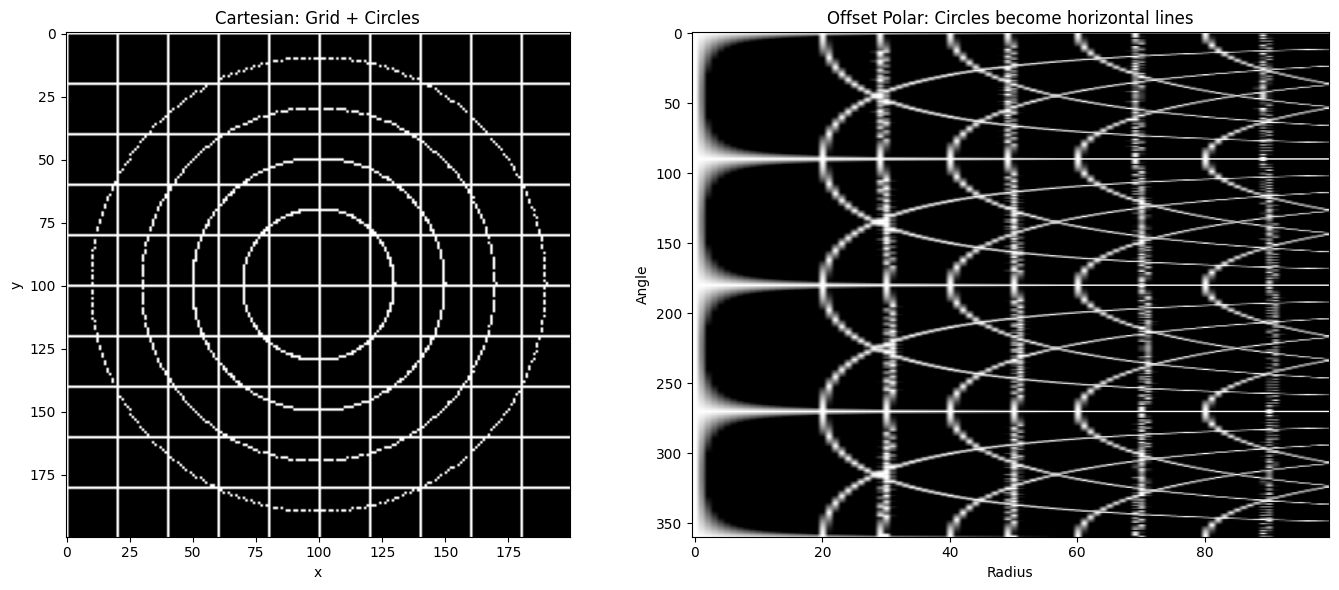

In [10]:
test_image = np.zeros((200, 200))
# Draw grid lines
for i in range(0, 200, 20):
    test_image[i, :] = 255
    test_image[:, i] = 255
# Draw circles
for r in [30, 50, 70, 90]:
    angles = np.linspace(0, 2 * np.pi, 360)
    for angle in angles:
        x = int(100 + r * np.cos(angle))
        y = int(100 + r * np.sin(angle))
        if 0 <= y < 200 and 0 <= x < 200:
            test_image[y, x] = 255

# Transform to offset polar
test_center = (100, 100)
test_max_radius = 100
test_polar_shape = (360, 100)


def test_warp_to_polar(output_coords):
    return inverse_offset_polar_to_cartesian_mapping(
        output_coords, 360, 100, test_max_radius, test_center
    )


test_polar = warp(
    test_image,
    test_warp_to_polar,
    output_shape=test_polar_shape,
    order=1,
    preserve_range=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Cartesian: Grid + Circles")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].imshow(test_polar, cmap="gray", aspect="auto")
axes[1].set_title("Offset Polar: Circles become horizontal lines")
axes[1].set_xlabel("Radius")
axes[1].set_ylabel("Angle")

plt.tight_layout()
plt.show()